In [3]:
from google.colab import files
uploaded = files.upload()

Saving meta-Montana.json to meta-Montana.json


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# Initialize Spark
spark = SparkSession.builder.appName("Montana_Analysis").getOrCreate()

# Explicit Schema for performance
schema = StructType([
    StructField("name", StringType(), True),
    StructField("address", StringType(), True),
    StructField("gmap_id", StringType(), True),
    StructField("latitude", DoubleType(), True),
    StructField("longitude", DoubleType(), True),
    StructField("category", ArrayType(StringType()), True),
    StructField("avg_rating", DoubleType(), True),
    StructField("num_of_reviews", IntegerType(), True),
    StructField("hours", ArrayType(ArrayType(StringType())), True),
    StructField("relative_results", ArrayType(StringType()), True)
])

df = spark.read.json("meta-Montana.json", schema=schema).dropDuplicates(["gmap_id"])

In [5]:
df.show(5, truncate=True)

+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+----------+--------------+--------------------+--------------------+
|                name|             address|             gmap_id|          latitude|          longitude|            category|avg_rating|num_of_reviews|               hours|    relative_results|
+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+----------+--------------+--------------------+--------------------+
|American Legion D...|American Legion D...|0x410755de15ccd36...|        46.6211146|       -112.0975357|[Veterans organiz...|       4.7|             6|                NULL|[0x5343545e5ed688...|
|Blue Ribbon of Mo...|Blue Ribbon of Mo...|0x4107db74133f3a4...|        47.5249246|-111.30597279999999|         [Gift shop]|       4.7|            54|[[Tuesday, 10AM–4...|[0x5342379127be5a...|
|Malmstrom Main Ex...|Malmstrom Mai

In [6]:
#Data Quality Check

In [7]:
print("Total records:", df.count())
df.printSchema()

Total records: 21534
root
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- gmap_id: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- category: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- avg_rating: double (nullable = true)
 |-- num_of_reviews: integer (nullable = true)
 |-- hours: array (nullable = true)
 |    |-- element: array (containsNull = true)
 |    |    |-- element: string (containsNull = true)
 |-- relative_results: array (nullable = true)
 |    |-- element: string (containsNull = true)



In [8]:
#Missing Values Check

In [9]:
from pyspark.sql.functions import col, count, when
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+----+-------+-------+--------+---------+--------+----------+--------------+-----+----------------+
|name|address|gmap_id|latitude|longitude|category|avg_rating|num_of_reviews|hours|relative_results|
+----+-------+-------+--------+---------+--------+----------+--------------+-----+----------------+
|   0|    304|      0|       0|        0|      89|         0|             0| 6649|            2738|
+----+-------+-------+--------+---------+--------+----------+--------------+-----+----------------+



I will delete the rows with missing categories to keep the charts accurate, and I will only use businesses that have listed hours for the nightlife analysis.

In [10]:
#Duplicate Detection

In [11]:
total_count = df.count()
unique_count = df.select("gmap_id").distinct().count()

print(f"Total Rows: {total_count}")
print(f"Unique Business IDs: {unique_count}")
print(f"Duplicate Rows: {total_count - unique_count}")

if total_count > unique_count:
    df = df.dropDuplicates(["gmap_id"])

Total Rows: 21534
Unique Business IDs: 21534
Duplicate Rows: 0


In [12]:
#Consistency Check of Quantitative Attributes

In [13]:
df.describe(["avg_rating", "num_of_reviews"]).show()

+-------+-----------------+------------------+
|summary|       avg_rating|    num_of_reviews|
+-------+-----------------+------------------+
|  count|            21534|             21534|
|   mean|4.383003622178909| 89.67716169778025|
| stddev|0.595542948265207|210.93804417172242|
|    min|              1.0|                 1|
|    max|              5.0|              9788|
+-------+-----------------+------------------+



The descriptive statistics confirm the consistency of the dataset.

In [14]:
#Check for Businesses Without Categories

In [15]:
from pyspark.sql.functions import size

empty_categories = df.filter(size(col("category")) == 0).count()
print(f"Rows with empty category lists: {empty_categories}")

Rows with empty category lists: 0


In [16]:
# EDA - most popular categories, highest rated categories, etc, + VISUALIZE

In [17]:
df_clean = df.dropna(subset=["category"])

df_exploded = df_clean.withColumn("category_single", F.explode("category"))

df_exploded.cache()

DataFrame[name: string, address: string, gmap_id: string, latitude: double, longitude: double, category: array<string>, avg_rating: double, num_of_reviews: int, hours: array<array<string>>, relative_results: array<string>, category_single: string]

In [18]:
#Top 10 Most Popular Categories

In [19]:
top_10_popular = df_exploded.groupBy("category_single") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(10)

top_10_popular.show()

+--------------------+-----+
|     category_single|count|
+--------------------+-----+
|          Restaurant| 1150|
|                 Bar|  703|
|         Gas station|  661|
|  Tourist attraction|  576|
|          Campground|  482|
|    Auto repair shop|  475|
|         Coffee shop|  474|
|Fast food restaurant|  450|
|               Hotel|  438|
| American restaurant|  430|
+--------------------+-----+



In [20]:
#Top 10 Highest Rated Categories

In [21]:
top_rated_cats = df_exploded.filter("num_of_reviews >= 10") \
    .groupBy("category_single") \
    .agg(
        F.avg("avg_rating").alias("mean_rating"),
        F.count("category_single").alias("frequency")
    ) \
    .filter("frequency >= 5") \
    .orderBy(F.desc("mean_rating")) \
    .limit(10)

top_rated_cats.show()

+-------------------+-----------------+---------+
|    category_single|      mean_rating|frequency|
+-------------------+-----------------+---------+
|     Home inspector|              5.0|        5|
|Photography service|4.959999999999999|        5|
| Photography studio|             4.92|        5|
|Pain control clinic|4.916666666666667|        6|
|       Chiropractor|4.892857142857145|       56|
|  Pediatric dentist|4.887500000000002|       24|
|            Surgeon|4.883333333333334|        6|
|   Wellness program|4.883333333333334|        6|
| Physical therapist|4.882352941176471|       17|
|         Art studio|4.880000000000001|        5|
+-------------------+-----------------+---------+



In [22]:
#Visualization

In [25]:
import plotly.express as px

pop_pd = top_10_popular.toPandas()

fig = px.bar(
    pop_pd,
    x='count',
    y='category_single',
    color='count',
    orientation='h',
    hover_data={'count': True},
    text=None,
    title='Top 10 Most Popular Business Categories in Montana'
)

fig.update_layout(
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

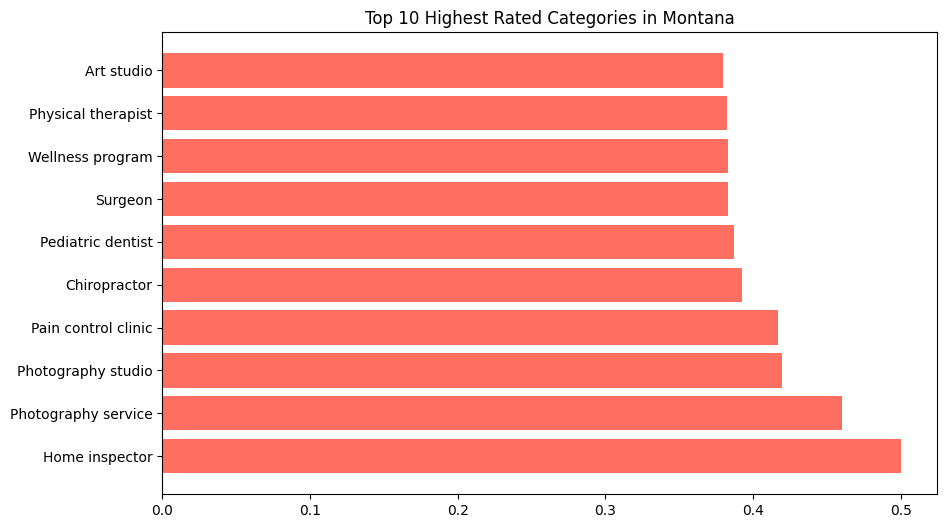

In [27]:
import matplotlib.pyplot as plt
import numpy as np

rate_pd = top_rated_cats.toPandas()

rate_pd['deviation'] = rate_pd['mean_rating'] - 4.5
y_pos = np.arange(len(rate_pd))

colors = ['#FF6F61' if x > 0 else '#6B5B95' for x in rate_pd['deviation']]

plt.figure(figsize=(10,6))
plt.barh(y_pos, rate_pd['deviation'], color=colors)
plt.yticks(y_pos, rate_pd['category_single'])
plt.xlabel
plt.title("Top 10 Highest Rated Categories in Montana")

plt.grid(False)

plt.show()

In [28]:
#Analyze the nightlife (9pm to 6am) | weekends vs weekdays | VISUALIZE

In [29]:
#Filter non-null hours

In [32]:
df_hours = df.filter(col("hours").isNotNull())

In [34]:
#Define Nightlife Logic

In [35]:
from pyspark.sql.functions import udf
from pyspark.sql.types import BooleanType

# Function to check if business is open at night (9 PM – 6 AM)
def check_nightlife(hours_list, is_weekend):
    night_keywords = ["9PM", "10PM", "11PM", "12AM", "1AM", "2AM", "3AM", "4AM", "5AM", "24 HOURS"]

    weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday"]
    weekends = ["Friday", "Saturday", "Sunday"]

    target_days = weekends if is_weekend else weekdays

    for day_info in hours_list:
        day_name = day_info[0]
        time_range = day_info[1].upper()

        if day_name in target_days:
            if any(key in time_range for key in night_keywords):
                return True
    return False

is_weekday_night = udf(lambda x: check_nightlife(x, False), BooleanType())
is_weekend_night = udf(lambda x: check_nightlife(x, True), BooleanType())

In [36]:
#Apply UDF to DataFrame

In [37]:
df_nightlife = df_hours.withColumn("is_weekday_nightlife", is_weekday_night("hours")) \
                       .withColumn("is_weekend_nightlife", is_weekend_night("hours"))

In [38]:
df_nightlife.head()

Row(name='Blue Ribbon of Montana', address='Blue Ribbon of Montana, 325 Smelter Ave NE, Great Falls, MT 59404', gmap_id='0x4107db74133f3a47:0x2586b3337e33a5ba', latitude=47.5249246, longitude=-111.30597279999999, category=['Gift shop'], avg_rating=4.7, num_of_reviews=54, hours=[['Tuesday', '10AM–4PM'], ['Wednesday', '10AM–4PM'], ['Thursday', '10AM–4PM'], ['Friday', '10AM–4PM'], ['Saturday', '10AM–5PM'], ['Sunday', 'Closed'], ['Monday', 'Closed']], relative_results=['0x5342379127be5adf:0xbaba973fb7f00da1', '0x534237ee18aedba7:0xe23a4dece84854ff', '0x534237ed9e513e19:0xd94bdf7169570a11', '0x534237ed0c1f1533:0x1e4cd0f4562f698'], is_weekday_nightlife=False, is_weekend_nightlife=False)

In [39]:
#Aggregate Nightlife Counts

In [41]:
nightlife_counts = df_nightlife.select(
    col("is_weekday_nightlife").cast("int").alias("Weekday_Nightlife"),
    col("is_weekend_nightlife").cast("int").alias("Weekend_Nightlife")
).groupBy().sum().toPandas()

nightlife_counts.columns = ["Weekday_Nightlife", "Weekend_Nightlife"]
print(nightlife_counts)

   Weekday_Nightlife  Weekend_Nightlife
0               5086               5563


In [42]:
nightlife_long = nightlife_counts.melt(var_name="Day_Type", value_name="Number_of_Businesses")

fig = px.bar(
    nightlife_long,
    x="Number_of_Businesses",
    y="Day_Type",
    color="Day_Type",
    orientation='h',
    text="Number_of_Businesses",
    title="Businesses Open During Night (9PM–6AM) in Montana",
    color_discrete_sequence=['#FF6F61', '#6B5B95']
)

fig.update_layout(
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    showlegend=False
)

fig.show()

In [44]:
 #Why "relative_results" are relative results? What features/categories connect them?

In [45]:
#Prepare relative results

In [46]:
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import explode, avg

df_rel = df.select(
    F.col("gmap_id").alias("original_id"),
    F.col("category").alias("original_categories"),
    explode("relative_results").alias("relative_id")
)

In [47]:
#Join to get relative categories

In [48]:
df_connected = df_rel.join(
    df.select(F.col("gmap_id"), F.col("category").alias("relative_categories")),
    df_rel.relative_id == df.gmap_id,
    "inner"
)

In [50]:
 #Count shared categories(Measures similarity between a business and its relatives).

In [51]:
def count_shared(cat1, cat2):
    if not cat1 or not cat2:
        return 0
    return len(set(cat1).intersection(set(cat2)))

shared_udf = F.udf(count_shared, IntegerType())

df_analysis = df_connected.withColumn(
    "shared_count", shared_udf("original_categories", "relative_categories")
)

In [ ]:
#Aggregate results(Check how similar relatives are).

In [52]:
avg_shared = df_analysis.select(avg("shared_count")).collect()[0][0]
print(f"On average, relative results share {avg_shared:.2f} categories.")

percent_shared = df_analysis.withColumn(
    "shared_flag", F.when(col("shared_count") > 0, 1).otherwise(0)
).select(avg("shared_flag")).collect()[0][0]

print(f"{percent_shared*100:.2f}% of relative results share at least one category.")

On average, relative results share 0.87 categories.
63.95% of relative results share at least one category.


In [62]:
#Most businesses share at least one category with their 'relative' neighbors, which proves they are usually similar types of places.

In [65]:
from pyproj import Proj
from scipy.spatial import cKDTree
pdf = df.select("gmap_id", "name", "latitude", "longitude", "category").toPandas()

In [66]:
#latitude/longitude to UTM (meters)

In [67]:
p = Proj(proj='utm', zone=12, ellps='WGS84')
pdf['easting'], pdf['northing'] = p(pdf['longitude'].values, pdf['latitude'].values)

In [68]:
#Build KD-Tree for fast nearest neighbor search

In [69]:
points = pdf[['easting', 'northing']].values
tree = cKDTree(points)

In [70]:
#Find top 5 closest points for each business

In [71]:
distances, indices = tree.query(points, k=6)

neighbors_list = []
for i, idx_list in enumerate(indices):
    for j, neighbor_idx in enumerate(idx_list[1:6]):
        neighbors_list.append({
            'business_id': pdf.iloc[i]['gmap_id'],
            'business_name': pdf.iloc[i]['name'],
            'neighbor_id': pdf.iloc[neighbor_idx]['gmap_id'],
            'neighbor_name': pdf.iloc[neighbor_idx]['name'],
            'distance_m': distances[i][j+1],
            'neighbor_category': pdf.iloc[neighbor_idx]['category']
        })

neighbors_df = pd.DataFrame(neighbors_list)

In [72]:
#Analyze types of venues among closest neighbors.

In [73]:
neighbors_exploded = neighbors_df.explode('neighbor_category')

category_counts = neighbors_exploded.groupby('neighbor_category').size().reset_index(name='count')
category_counts = category_counts.sort_values(by='count', ascending=False)

In [75]:
category_counts

,neighbor_category,count
1768,Restaurant,6342
185,Bar,3913
917,Gas station,3817
462,Coffee shop,2589
788,Fast food restaurant,2494
...,...,...
774,Family day care service,1
791,Federal courthouse,1
1437,New Age church,1
1105,Ice skating club,1


In [74]:
top_categories = category_counts.head(15)

fig = px.bar(
    top_categories,
    x='count',
    y='neighbor_category',
    orientation='h',
    text='count',
    color='count',
    color_continuous_scale='Viridis',
    title="Most Common Venue Types Among 5 Closest Neighbors"
)

fig.update_layout(
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    showlegend=False
)

fig.show()

In [76]:
#We can conclude, that in Montana, the most common "neighbor pairs" are not random.